# Bank Marketing — Model Building (v2)

**Problem statement:** predict whether a customer will subscribe to a term deposit, using only information known **before** a call is made, so the bank can prioritize who to call next.

**Fixes vs. the previous modeling notebook:**
1. Loads the properly-leakage-checked, pre-split feature sets from the EDA notebook (`df_train_deploy.csv`, `df_test_deploy.csv`, `df_train_full.csv`, `df_test_full.csv`) instead of an ad-hoc `df.csv`/`df1.csv` — split was done stratified, before any feature-selection decisions.
2. Handles **class imbalance** (~88.7% no / 11.3% yes) with `class_weight='balanced'` instead of ignoring it.
3. Evaluates with **precision, recall, F1, ROC-AUC, PR-AUC** — not just accuracy, which is misleading on imbalanced data.
4. Adds **stratified cross-validation** instead of trusting a single train/test split.
5. Adds **feature scaling** (fit on train only) for models that need it (Logistic Regression, Naive Bayes).
6. Removes duplicated/inconsistent model-refitting — each model is trained once, evaluated once, in a loop.
7. Adds **ROC and Precision-Recall curve comparison**, feature importance/coefficients, and **threshold tuning** (default 0.5 is rarely optimal under imbalance).
8. Adds a lightweight **hyperparameter search** for the best base model.
9. Trains on `deploy` features (no `duration`) for the real model, and separately on `full` features (with `duration`) only as an upper-bound reference — never mixes the two.
10. Saves the final chosen model to disk.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import joblib
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42


c:\Users\shraw\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Load the prepared datasets

These four files come straight out of the EDA notebook — already stratified-split, deduplicated, and leakage-checked. `deploy` excludes `duration`; `full` includes it purely as an upper-bound reference, never for the real model.

In [2]:
df_train_deploy = pd.read_csv('df_train_deploy.csv')
df_test_deploy  = pd.read_csv('df_test_deploy.csv')
df_train_full   = pd.read_csv('df_train_full.csv')
df_test_full    = pd.read_csv('df_test_full.csv')

print("deploy train/test:", df_train_deploy.shape, df_test_deploy.shape)
print("full   train/test:", df_train_full.shape, df_test_full.shape)
print()
print("Train class balance (deploy):")
print(df_train_deploy['y'].value_counts(normalize=True).round(4) * 100)
print()
print("'duration' present in deploy set:", 'duration' in df_train_deploy.columns)
print("'duration' present in full set:  ", 'duration' in df_train_full.columns)


deploy train/test: (32940, 28) (8236, 28)
full   train/test: (32940, 29) (8236, 29)

Train class balance (deploy):
y
0    88.73
1    11.27
Name: proportion, dtype: float64

'duration' present in deploy set: False
'duration' present in full set:   True


## 2. Split into X / y

In [3]:
def split_xy(df, target='y'):
    X = df.drop(columns=[target])
    y = df[target]
    return X, y

X_train, y_train = split_xy(df_train_deploy)
X_test,  y_test  = split_xy(df_test_deploy)

X_train_full, y_train_full = split_xy(df_train_full)
X_test_full,  y_test_full  = split_xy(df_test_full)

print(X_train.shape, X_test.shape)


(32940, 27) (8236, 27)


## 3. Feature scaling

Logistic Regression and Naive Bayes are sensitive to feature scale (`age`, `pdays`, `euribor3m`, `nr.employed` all live on very different scales). Tree-based models (Decision Tree, Random Forest, Gradient Boosting) are scale-invariant, so we keep an unscaled copy for them.

**Important:** the scaler is `fit` on train only, then used to `transform` test — fitting on the full dataset would leak test-set statistics into training.

In [4]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)


## 4. Handling class imbalance

~88.7% "no" vs ~11.3% "yes". Instead of resampling (SMOTE/undersampling), we start with `class_weight='balanced'`, which reweights the loss function to penalize misclassifying the minority class more — simpler, no synthetic data, and a good baseline before reaching for resampling.

Note: `GaussianNB` has no `class_weight` parameter — a known limitation, called out explicitly rather than silently ignored.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    'Naive Bayes': GaussianNB(),  # no class_weight support — flagged, not ignored
}

# Which models need the scaled features
needs_scaling = {'Logistic Regression', 'Naive Bayes'}


## 5. Stratified cross-validation (on training data only)

A single train/test split can be noisy. 5-fold stratified CV on the training set gives a more reliable estimate of each model's performance *before* we ever touch the test set, and keeps the class ratio consistent in every fold.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = []
for name, model in models.items():
    X_cv = X_train_scaled if name in needs_scaling else X_train
    scores = cross_validate(model, X_cv, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'model': name}
    for s in scoring:
        row[f'{s}_mean'] = scores[f'test_{s}'].mean()
        row[f'{s}_std'] = scores[f'test_{s}'].std()
    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results).sort_values('f1_mean', ascending=False)
cv_results_df


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.829933,0.005849,0.354127,0.012901,0.617620,0.018584,0.450107,0.014771,0.789618,0.007503
4,Naive Bayes,0.873103,0.003261,0.435170,0.014548,0.423331,0.015281,0.429090,0.013786,0.770627,0.009682
2,Random Forest,0.878719,0.002183,0.447752,0.012784,0.326869,0.011138,0.377783,0.010348,0.761468,0.008369
3,Gradient Boosting,0.900395,0.001528,0.655703,0.025049,0.245217,0.004328,0.356801,0.005243,0.795944,0.007461
1,Decision Tree,0.834092,0.003223,0.301506,0.007608,0.358667,0.011519,0.327526,0.007802,0.630550,0.005015


## 6. Fit on full training set, evaluate once on the held-out test set

Cross-validation told us roughly what to expect. Now fit each model on the *entire* training set and evaluate on the test set exactly once — this is the number that mimics real deployment.

===== Logistic Regression =====
              precision    recall  f1-score   support

          no       0.95      0.85      0.90      7308
         yes       0.36      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.66      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



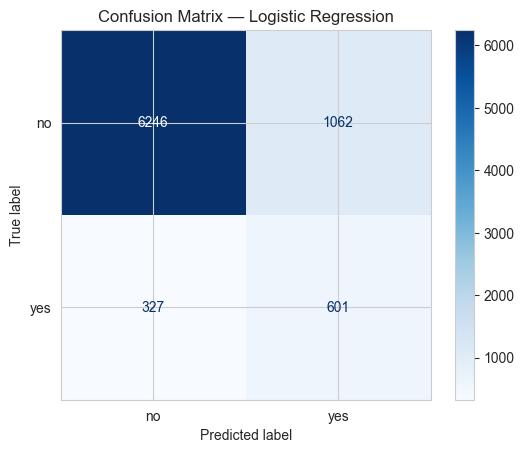

===== Decision Tree =====
              precision    recall  f1-score   support

          no       0.91      0.89      0.90      7308
         yes       0.29      0.34      0.32       928

    accuracy                           0.83      8236
   macro avg       0.60      0.62      0.61      8236
weighted avg       0.84      0.83      0.84      8236



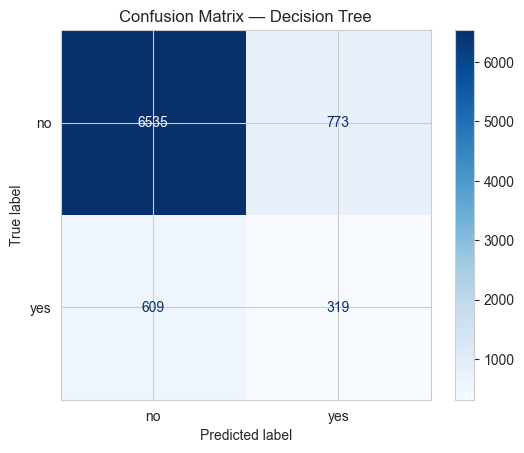

===== Random Forest =====
              precision    recall  f1-score   support

          no       0.92      0.95      0.93      7308
         yes       0.43      0.32      0.37       928

    accuracy                           0.88      8236
   macro avg       0.67      0.63      0.65      8236
weighted avg       0.86      0.88      0.87      8236



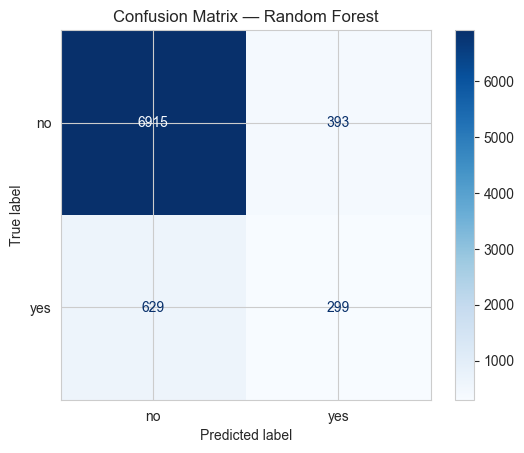

===== Gradient Boosting =====
              precision    recall  f1-score   support

          no       0.91      0.98      0.95      7308
         yes       0.65      0.23      0.34       928

    accuracy                           0.90      8236
   macro avg       0.78      0.61      0.64      8236
weighted avg       0.88      0.90      0.88      8236



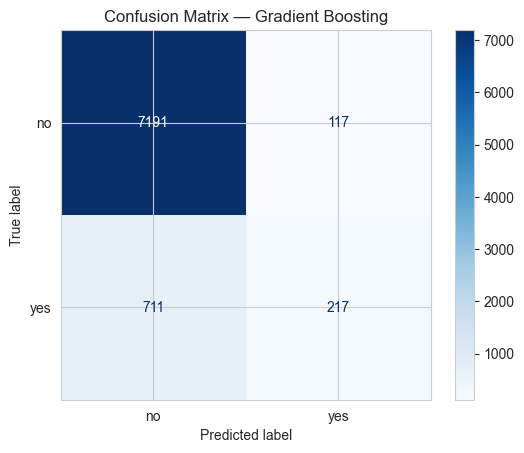

===== Naive Bayes =====
              precision    recall  f1-score   support

          no       0.93      0.93      0.93      7308
         yes       0.43      0.43      0.43       928

    accuracy                           0.87      8236
   macro avg       0.68      0.68      0.68      8236
weighted avg       0.87      0.87      0.87      8236



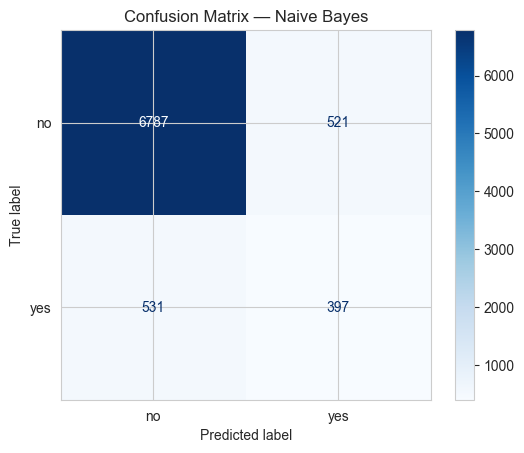

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.831350,0.361395,0.647629,0.463914,0.795627,0.445386
4,Naive Bayes,0.872268,0.432462,0.427802,0.430119,0.775130,0.361100
2,Random Forest,0.875911,0.432081,0.322198,0.369136,0.763302,0.380510
3,Gradient Boosting,0.899466,0.649701,0.233836,0.343899,0.806396,0.465833
1,Decision Tree,0.832200,0.292125,0.343750,0.315842,0.623367,0.195282


In [7]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    result = {
        'model': name,
        'accuracy': accuracy_score(y_te, pred),
        'precision': precision_score(y_te, pred),
        'recall': recall_score(y_te, pred),
        'f1': f1_score(y_te, pred),
    }
    if proba is not None:
        result['roc_auc'] = roc_auc_score(y_te, proba)
        result['pr_auc'] = average_precision_score(y_te, proba)

    print(f"===== {name} =====")
    print(classification_report(y_te, pred, target_names=['no', 'yes']))
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.show()

    return result, model, proba

test_results = []
fitted_models = {}
test_probas = {}

for name, model in models.items():
    if name in needs_scaling:
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    result, fitted, proba = evaluate_model(name, model, X_tr, y_train, X_te, y_test)
    test_results.append(result)
    fitted_models[name] = fitted
    test_probas[name] = proba

test_results_df = pd.DataFrame(test_results).sort_values('f1', ascending=False)
test_results_df


## 7. Compare models side by side

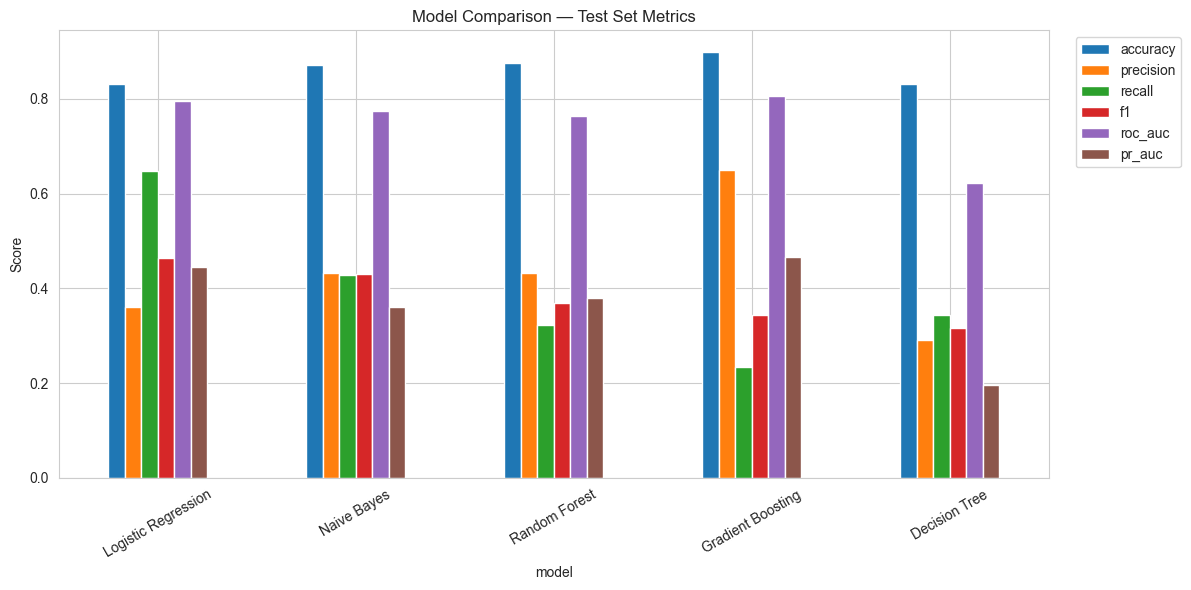

In [8]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
plot_df = test_results_df.set_index('model')[metrics_to_plot]

plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Comparison — Test Set Metrics')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 8. ROC curves

Useful, but with ~88/11 imbalance the Precision-Recall curve below is usually more informative — ROC-AUC can look deceptively good even for a weak minority-class classifier.

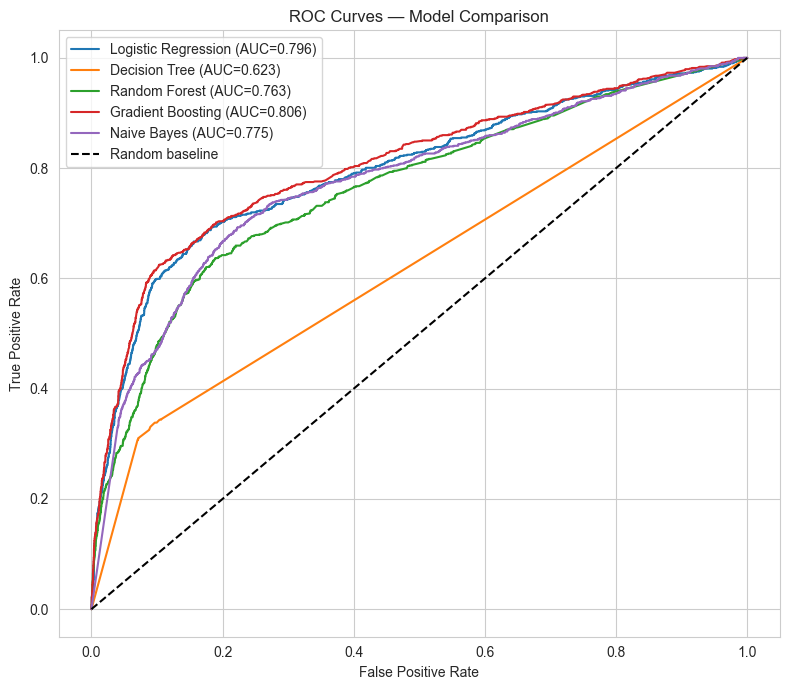

In [9]:
plt.figure(figsize=(8, 7))
for name, proba in test_probas.items():
    if proba is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Precision-Recall curves (more informative under class imbalance)

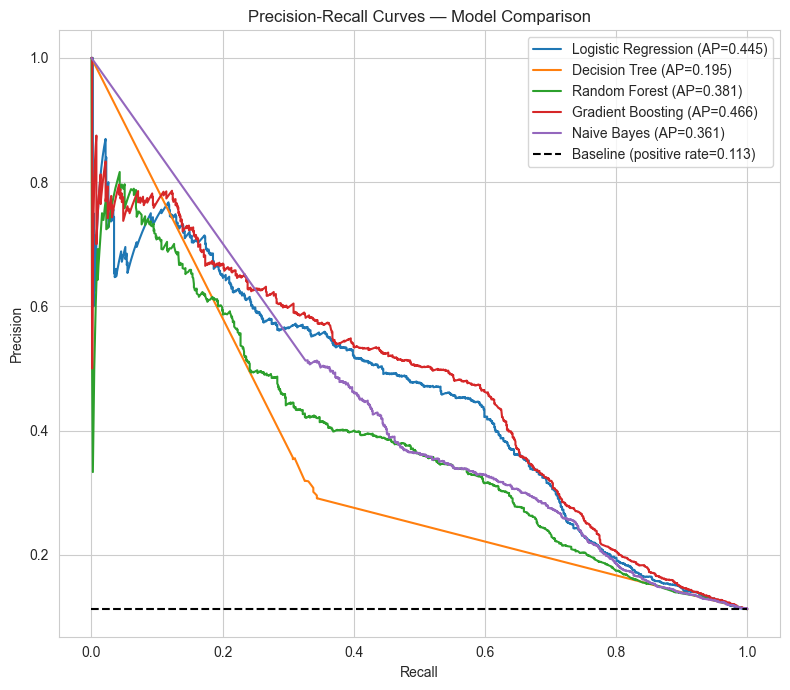

In [10]:
baseline_rate = y_test.mean()

plt.figure(figsize=(8, 7))
for name, proba in test_probas.items():
    if proba is None:
        continue
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')

plt.hlines(baseline_rate, 0, 1, colors='k', linestyles='--',
           label=f'Baseline (positive rate={baseline_rate:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()


## 10. Feature importance / coefficients

Interview-friendly: shows *which* features each model actually leans on, not just how well it scores.

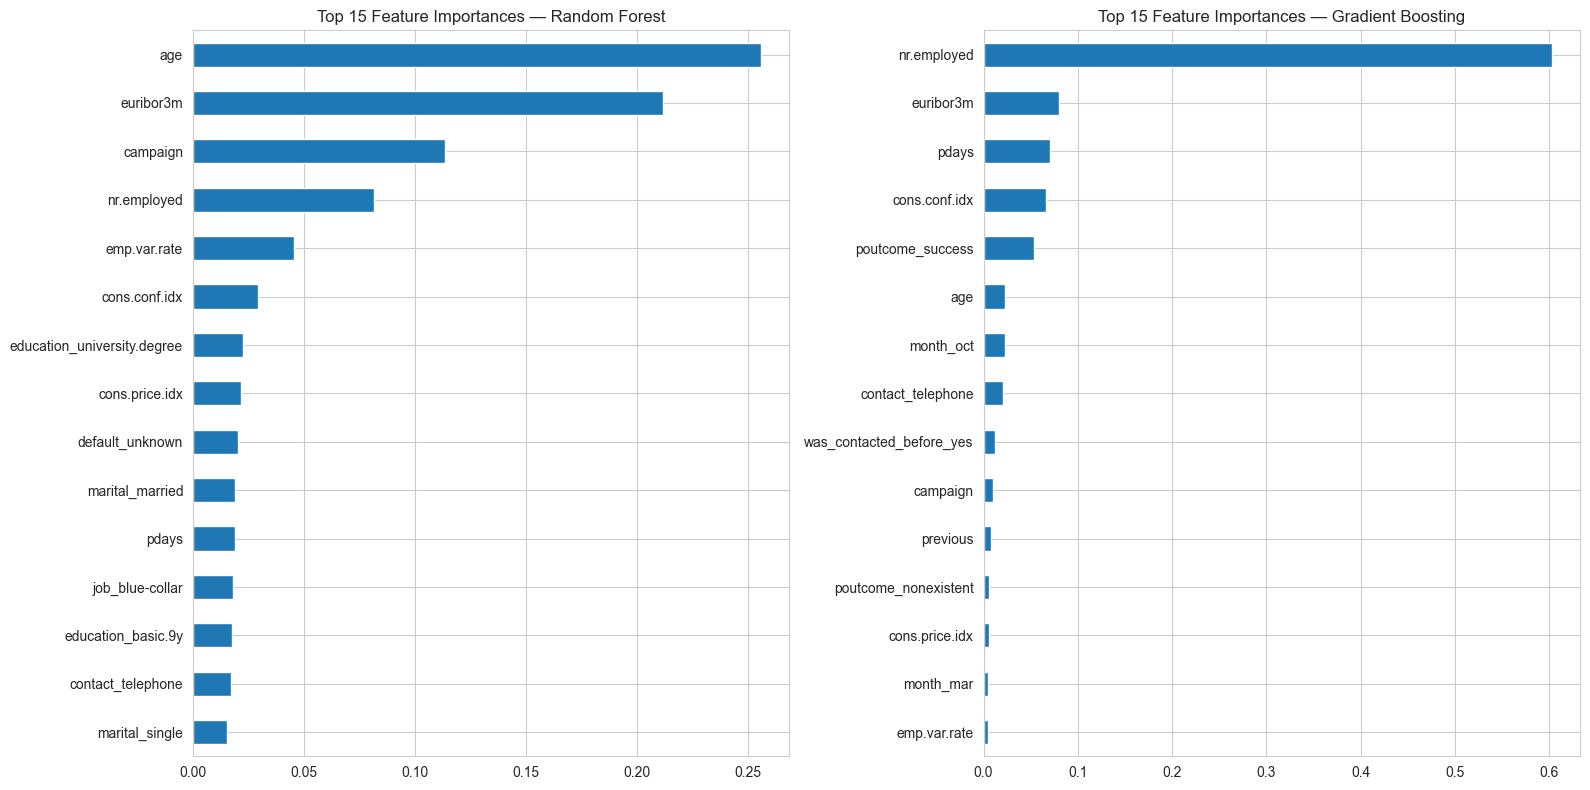

In [11]:
# Tree-based feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    model = fitted_models[name]
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(15)
    importances.sort_values().plot(kind='barh', ax=ax)
    ax.set_title(f'Top 15 Feature Importances — {name}')

plt.tight_layout()
plt.show()


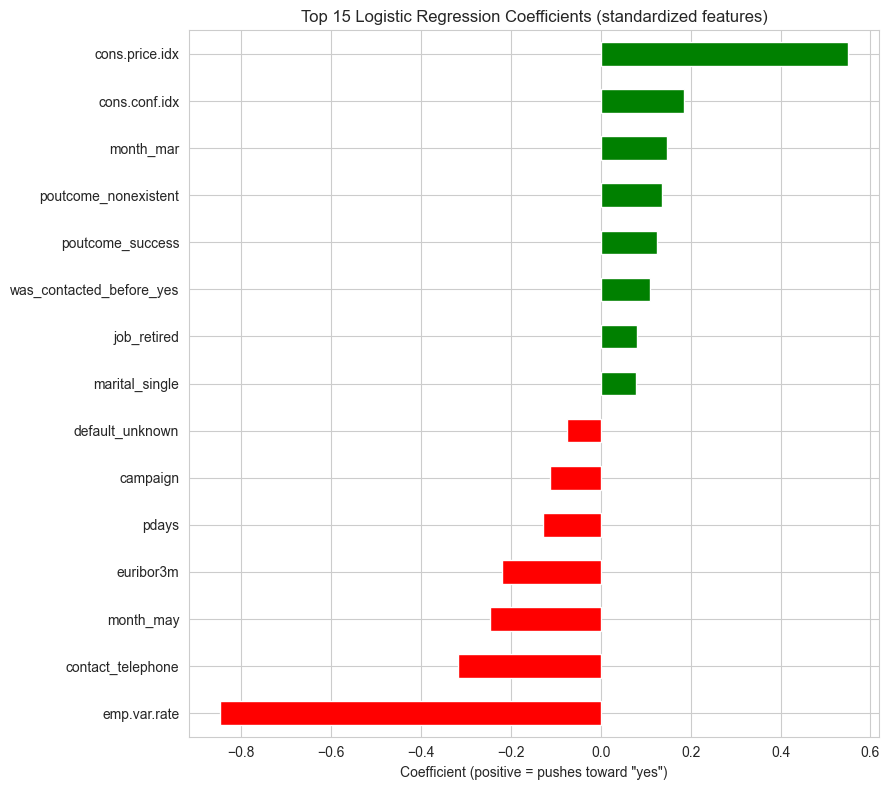

In [12]:
# Logistic Regression coefficients (on scaled features, so magnitudes are comparable)
log_model = fitted_models['Logistic Regression']
coefs = pd.Series(log_model.coef_[0], index=X_train_scaled.columns)
top_coefs = coefs.reindex(coefs.abs().sort_values(ascending=False).head(15).index)

plt.figure(figsize=(9, 8))
top_coefs.sort_values().plot(kind='barh', color=top_coefs.sort_values().apply(lambda v: 'green' if v > 0 else 'red'))
plt.title('Top 15 Logistic Regression Coefficients (standardized features)')
plt.xlabel('Coefficient (positive = pushes toward "yes")')
plt.tight_layout()
plt.show()


## 11. Threshold tuning

Every model above uses the default 0.5 probability threshold for `predict()`. Under class imbalance, that default is rarely optimal — if the business cares more about catching subscribers (recall) than avoiding false positives, a lower threshold usually helps. Here we sweep thresholds for the best model by F1 and show the trade-off.

Tuning threshold for: Logistic Regression
threshold    0.630000
precision    0.440191
recall       0.594828
f1           0.505958
Name: 29, dtype: float64


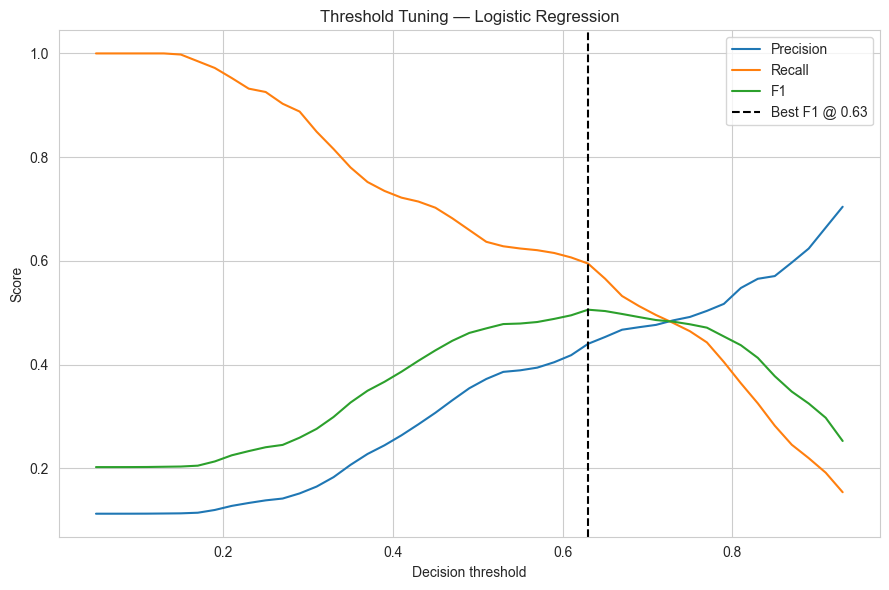

In [13]:
best_model_name = test_results_df.iloc[0]['model']
print("Tuning threshold for:", best_model_name)

proba = test_probas[best_model_name]
thresholds = np.arange(0.05, 0.95, 0.02)

rows = []
for t in thresholds:
    pred_t = (proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)
best_threshold_row = threshold_df.loc[threshold_df['f1'].idxmax()]
print(best_threshold_row)

plt.figure(figsize=(9, 6))
plt.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision')
plt.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1'], label='F1')
plt.axvline(best_threshold_row['threshold'], color='k', linestyle='--',
            label=f"Best F1 @ {best_threshold_row['threshold']:.2f}")
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title(f'Threshold Tuning — {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()


## 12. Light hyperparameter search on the best model

A small randomized search rather than an exhaustive grid — cheaper, and usually gets close to the same result. Adjust `param_distributions` per model if the best model isn't Random Forest.

In [14]:
param_distributions = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=20,
    scoring='f1',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV F1:", rf_search.best_score_)

tuned_rf = rf_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test)
tuned_proba = tuned_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, tuned_pred, target_names=['no', 'yes']))
print("Tuned ROC-AUC:", roc_auc_score(y_test, tuned_proba))
print("Tuned PR-AUC :", average_precision_score(y_test, tuned_proba))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}
Best CV F1: 0.4937465468713841
              precision    recall  f1-score   support

          no       0.95      0.90      0.92      7308
         yes       0.44      0.62      0.51       928

    accuracy                           0.87      8236
   macro avg       0.69      0.76      0.72      8236
weighted avg       0.89      0.87      0.88      8236

Tuned ROC-AUC: 0.7995290057660004
Tuned PR-AUC : 0.47666380994151


## 13. Reference only: same models trained on the `full` feature set (with `duration`)

**Not for deployment.** This exists purely to quantify how much of a lift `duration` gives — the gap between this table and the deploy-set table above *is* the leakage effect, and it's worth having the number ready for an interviewer who asks "what if you kept duration?".

In [15]:
full_results = []
for name, model in models.items():
    m = type(model)(**model.get_params())
    if name in needs_scaling:
        scaler_full = StandardScaler()
        X_tr = pd.DataFrame(scaler_full.fit_transform(X_train_full), columns=X_train_full.columns)
        X_te = pd.DataFrame(scaler_full.transform(X_test_full), columns=X_test_full.columns)
    else:
        X_tr, X_te = X_train_full, X_test_full

    m.fit(X_tr, y_train_full)
    pred = m.predict(X_te)
    proba = m.predict_proba(X_te)[:, 1] if hasattr(m, 'predict_proba') else None

    row = {
        'model': name,
        'accuracy': accuracy_score(y_test_full, pred),
        'precision': precision_score(y_test_full, pred),
        'recall': recall_score(y_test_full, pred),
        'f1': f1_score(y_test_full, pred),
    }
    if proba is not None:
        row['roc_auc'] = roc_auc_score(y_test_full, proba)
    full_results.append(row)

full_results_df = pd.DataFrame(full_results).sort_values('f1', ascending=False)

print("DEPLOY set (no duration) — realistic, deployable performance:")
display(test_results_df[['model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']])

print()
print("FULL set (with duration) — upper-bound / leakage-inflated reference only:")
display(full_results_df)


DEPLOY set (no duration) — realistic, deployable performance:


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.831350,0.361395,0.647629,0.463914,0.795627
4,Naive Bayes,0.872268,0.432462,0.427802,0.430119,0.775130
2,Random Forest,0.875911,0.432081,0.322198,0.369136,0.763302
3,Gradient Boosting,0.899466,0.649701,0.233836,0.343899,0.806396
1,Decision Tree,0.832200,0.292125,0.343750,0.315842,0.623367



FULL set (with duration) — upper-bound / leakage-inflated reference only:


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.863769,0.448073,0.901940,0.598712,0.939435
3,Gradient Boosting,0.917071,0.658885,0.547414,0.597999,0.948841
2,Random Forest,0.914643,0.668161,0.481681,0.559800,0.946675
1,Decision Tree,0.888538,0.505695,0.478448,0.491694,0.709531
4,Naive Bayes,0.876639,0.454262,0.470905,0.462434,0.854284


## 14. Final model selection & save

Pick the model with the best F1 (or recall, depending on the business objective) on the **deploy** set, and persist it for reuse — never the `full`-set version, since that one relies on information not available at prediction time.

In [16]:
final_model_name = test_results_df.iloc[0]['model']
final_model = fitted_models[final_model_name]

print(f"Selected model: {final_model_name}")

joblib.dump(final_model, 'final_model.pkl')
if final_model_name in needs_scaling:
    joblib.dump(scaler, 'scaler.pkl')
    print("Saved final_model.pkl and scaler.pkl (this model needs scaled inputs at inference time).")
else:
    print("Saved final_model.pkl (no scaling needed for this model type).")


Selected model: Logistic Regression
Saved final_model.pkl and scaler.pkl (this model needs scaled inputs at inference time).


1. Fix model selection — compare all final candidates properly

In [17]:
# Build a complete comparison including tuned RF and threshold-tuned LR,
# instead of picking iloc[0] from a table computed before tuning.

candidates = []

# Default-hyperparameter models already in test_results_df
for _, row in test_results_df.iterrows():
    candidates.append({
        'candidate': row['model'] + ' (default)',
        'f1': row['f1'], 'precision': row['precision'],
        'recall': row['recall'], 'roc_auc': row['roc_auc']
    })

# Tuned Random Forest
tuned_pred_final = (tuned_proba >= 0.5).astype(int)
candidates.append({
    'candidate': 'Random Forest (tuned)',
    'f1': f1_score(y_test, tuned_pred_final),
    'precision': precision_score(y_test, tuned_pred_final),
    'recall': recall_score(y_test, tuned_pred_final),
    'roc_auc': roc_auc_score(y_test, tuned_proba)
})

# Logistic Regression at tuned threshold (0.63 from your sweep)
lr_proba = test_probas['Logistic Regression']
lr_thresh_pred = (lr_proba >= best_threshold_row['threshold']).astype(int)
candidates.append({
    'candidate': f"Logistic Regression (threshold={best_threshold_row['threshold']:.2f})",
    'f1': f1_score(y_test, lr_thresh_pred),
    'precision': precision_score(y_test, lr_thresh_pred),
    'recall': recall_score(y_test, lr_thresh_pred),
    'roc_auc': roc_auc_score(y_test, lr_proba)
})

candidates_df = pd.DataFrame(candidates).sort_values('f1', ascending=False)
print(candidates_df)

best_candidate = candidates_df.iloc[0]['candidate']
print(f"\nBest candidate by F1: {best_candidate}")

                              candidate        f1  precision    recall  \
5                 Random Forest (tuned)  0.511191   0.437213  0.615302   
6  Logistic Regression (threshold=0.63)  0.505958   0.440191  0.594828   
0         Logistic Regression (default)  0.463914   0.361395  0.647629   
1                 Naive Bayes (default)  0.430119   0.432462  0.427802   
2               Random Forest (default)  0.369136   0.432081  0.322198   
3           Gradient Boosting (default)  0.343899   0.649701  0.233836   
4               Decision Tree (default)  0.315842   0.292125  0.343750   

    roc_auc  
5  0.799529  
6  0.795627  
0  0.795627  
1  0.775130  
2  0.763302  
3  0.806396  
4  0.623367  

Best candidate by F1: Random Forest (tuned)


2. Train vs. test gap — overfitting check

                   model  train_f1   test_f1       gap  train_acc  test_acc
1          Decision Tree  0.884331  0.315842  0.568489   0.970553  0.832200
2          Random Forest  0.901757  0.369136  0.532621   0.975896  0.875911
5  Random Forest (tuned)  0.564385  0.511191  0.053194   0.879842  0.867411
3      Gradient Boosting  0.389215  0.343899  0.045316   0.905100  0.899466
4            Naive Bayes  0.429312  0.430119 -0.000807   0.873042  0.872268
0    Logistic Regression  0.448996  0.463914 -0.014918   0.828476  0.831350


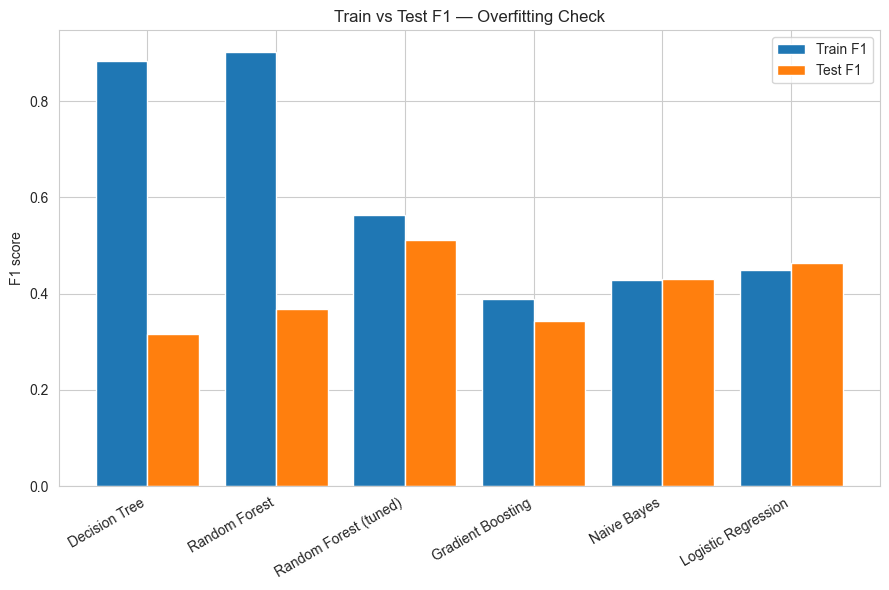

In [18]:
# Compare train and test performance for every fitted model.
# A big gap (train >> test) signals overfitting, not real signal.

overfit_check = []
for name, model in fitted_models.items():
    X_tr = X_train_scaled if name in needs_scaling else X_train
    X_te = X_test_scaled if name in needs_scaling else X_test

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    overfit_check.append({
        'model': name,
        'train_f1': f1_score(y_train, train_pred),
        'test_f1': f1_score(y_test, test_pred),
        'gap': f1_score(y_train, train_pred) - f1_score(y_test, test_pred),
        'train_acc': accuracy_score(y_train, train_pred),
        'test_acc': accuracy_score(y_test, test_pred),
    })

# Also check the tuned RF specifically
tuned_train_pred = tuned_rf.predict(X_train)
overfit_check.append({
    'model': 'Random Forest (tuned)',
    'train_f1': f1_score(y_train, tuned_train_pred),
    'test_f1': f1_score(y_test, tuned_pred_final),
    'gap': f1_score(y_train, tuned_train_pred) - f1_score(y_test, tuned_pred_final),
    'train_acc': accuracy_score(y_train, tuned_train_pred),
    'test_acc': accuracy_score(y_test, tuned_pred_final),
})

overfit_df = pd.DataFrame(overfit_check).sort_values('gap', ascending=False)
print(overfit_df)

plt.figure(figsize=(9, 6))
x = np.arange(len(overfit_df))
plt.bar(x - 0.2, overfit_df['train_f1'], width=0.4, label='Train F1')
plt.bar(x + 0.2, overfit_df['test_f1'], width=0.4, label='Test F1')
plt.xticks(x, overfit_df['model'], rotation=30, ha='right')
plt.ylabel('F1 score')
plt.title('Train vs Test F1 — Overfitting Check')
plt.legend()
plt.tight_layout()
plt.show()

3. Error analysis — look at actual false positives / false negatives

In [19]:
# Pick whichever model you're finalizing — swap 'tuned_rf' / 'tuned_proba' for
# another model + its probas if you go with Logistic Regression instead.

chosen_model_name = 'Random Forest (tuned)'
chosen_proba = tuned_proba
chosen_pred = tuned_pred_final

X_test_readable = X_test.copy()
X_test_readable['actual'] = y_test.values
X_test_readable['predicted'] = chosen_pred
X_test_readable['predicted_proba'] = chosen_proba

false_negatives = X_test_readable[(X_test_readable['actual'] == 1) & (X_test_readable['predicted'] == 0)]
false_positives = X_test_readable[(X_test_readable['actual'] == 0) & (X_test_readable['predicted'] == 1)]

print(f"False negatives (missed subscribers): {len(false_negatives)}")
print(f"False positives (wasted calls predicted): {len(false_positives)}")

# Where are the false negatives concentrated? Check a few key columns.
cols_to_check = [c for c in X_test.columns if c.startswith(('job_', 'poutcome_', 'contact_', 'month_'))]

print("\n--- False negatives: mean value per one-hot column (top 10 by rate) ---")
fn_rates = false_negatives[cols_to_check].mean().sort_values(ascending=False).head(10)
print(fn_rates)

print("\n--- All test data: same columns, for comparison ---")
overall_rates = X_test[cols_to_check].mean()
print(overall_rates[fn_rates.index])

# Where the model is most confidently wrong — biggest misses
false_negatives_sorted = false_negatives.sort_values('predicted_proba')
print("\n--- Most confidently-wrong false negatives (lowest predicted probability, but actually 'yes') ---")
print(false_negatives_sorted[['predicted_proba']].head(10))

false_positives_sorted = false_positives.sort_values('predicted_proba', ascending=False)
print("\n--- Most confidently-wrong false positives (highest predicted probability, but actually 'no') ---")
print(false_positives_sorted[['predicted_proba']].head(10))

False negatives (missed subscribers): 357
False positives (wasted calls predicted): 735

--- False negatives: mean value per one-hot column (top 10 by rate) ---
poutcome_nonexistent    0.899160
month_may               0.392157
contact_telephone       0.302521
job_blue-collar         0.246499
job_services            0.114846
job_retired             0.030812
job_student             0.022409
month_sep               0.008403
month_mar               0.002801
poutcome_success        0.002801
dtype: float64

--- All test data: same columns, for comparison ---
poutcome_nonexistent    0.864497
month_may               0.333657
contact_telephone       0.369111
job_blue-collar         0.220131
job_services            0.095435
job_retired             0.040068
job_student             0.022341
month_sep               0.013235
month_mar               0.013842
poutcome_success        0.033876
dtype: float64

--- Most confidently-wrong false negatives (lowest predicted probability, but actually 'yes') -

4. Calibration curve — is predict_proba actually trustworthy?

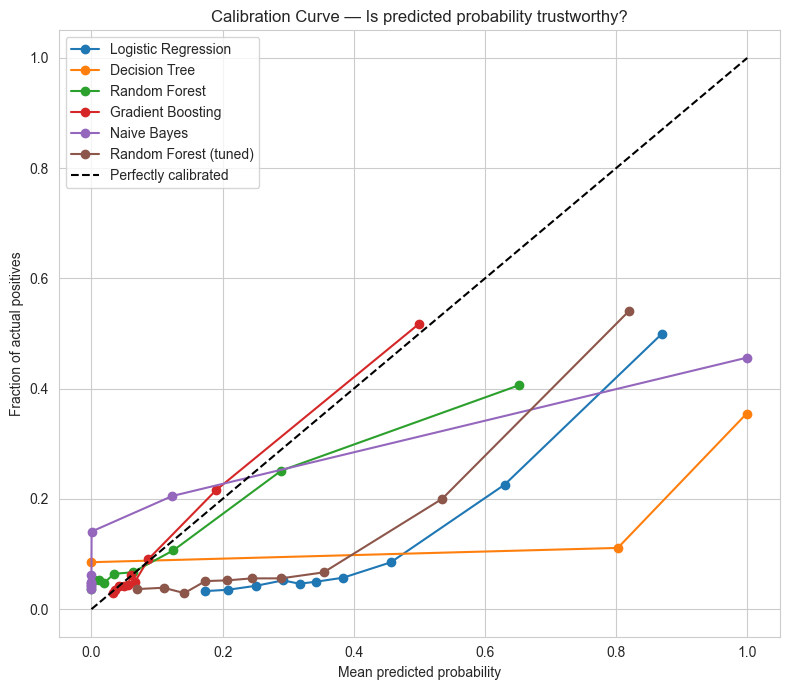

In [20]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 7))

for name, proba in test_probas.items():
    if proba is None:
        continue
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

# Add the tuned RF too
frac_pos_rf, mean_pred_rf = calibration_curve(y_test, tuned_proba, n_bins=10, strategy='quantile')
plt.plot(mean_pred_rf, frac_pos_rf, marker='o', label='Random Forest (tuned)')

plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of actual positives')
plt.title('Calibration Curve — Is predicted probability trustworthy?')
plt.legend()
plt.tight_layout()
plt.show()

Best Gradient Boosting threshold:
threshold    0.190000
precision    0.469684
recall       0.592672
f1           0.524059
Name: 7, dtype: float64


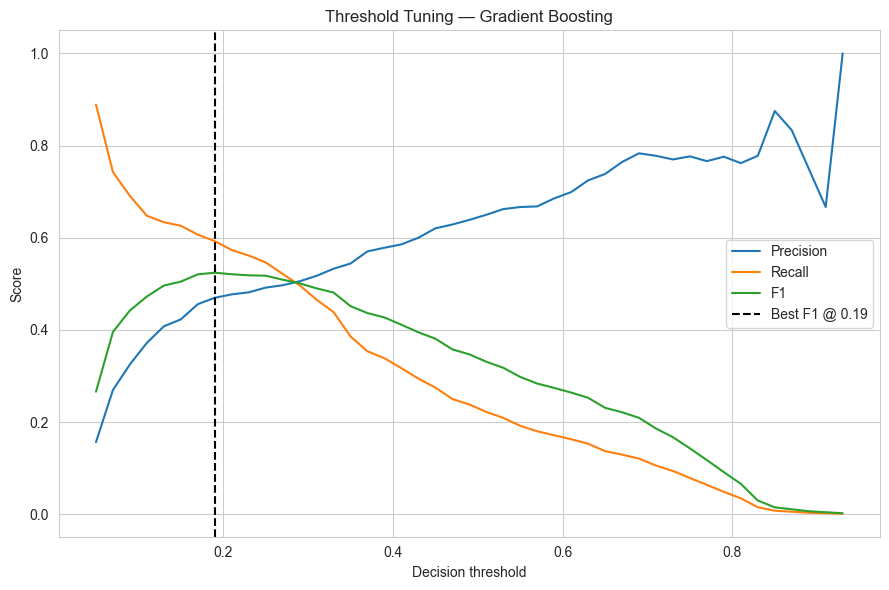

In [21]:
gb_proba = test_probas['Gradient Boosting']
thresholds = np.arange(0.05, 0.95, 0.02)

gb_rows = []
for t in thresholds:
    pred_t = (gb_proba >= t).astype(int)
    gb_rows.append({
        'threshold': t,
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
    })

gb_threshold_df = pd.DataFrame(gb_rows)
best_gb_row = gb_threshold_df.loc[gb_threshold_df['f1'].idxmax()]
print("Best Gradient Boosting threshold:")
print(best_gb_row)

plt.figure(figsize=(9, 6))
plt.plot(gb_threshold_df['threshold'], gb_threshold_df['precision'], label='Precision')
plt.plot(gb_threshold_df['threshold'], gb_threshold_df['recall'], label='Recall')
plt.plot(gb_threshold_df['threshold'], gb_threshold_df['f1'], label='F1')
plt.axvline(best_gb_row['threshold'], color='k', linestyle='--',
            label=f"Best F1 @ {best_gb_row['threshold']:.2f}")
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

Final model: Gradient Boosting @ threshold = 0.19
              precision    recall  f1-score   support

          no       0.95      0.92      0.93      7308
         yes       0.47      0.59      0.52       928

    accuracy                           0.88      8236
   macro avg       0.71      0.75      0.73      8236
weighted avg       0.89      0.88      0.88      8236

ROC-AUC: 0.8063955213228771
PR-AUC : 0.46583348768798477


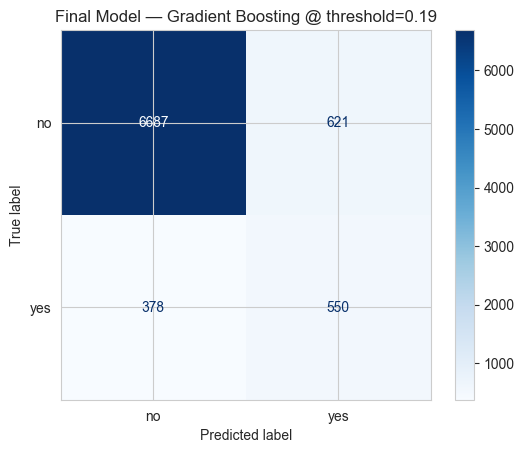

Saved final_model.pkl (Gradient Boosting + tuned threshold, no scaler needed)


In [22]:
GB_THRESHOLD = 0.19

gb_model = fitted_models['Gradient Boosting']
gb_final_pred = (test_probas['Gradient Boosting'] >= GB_THRESHOLD).astype(int)

print("Final model: Gradient Boosting @ threshold =", GB_THRESHOLD)
print(classification_report(y_test, gb_final_pred, target_names=['no', 'yes']))
print("ROC-AUC:", roc_auc_score(y_test, test_probas['Gradient Boosting']))
print("PR-AUC :", average_precision_score(y_test, test_probas['Gradient Boosting']))

cm = confusion_matrix(y_test, gb_final_pred)
ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(cmap='Blues')
plt.title(f'Final Model — Gradient Boosting @ threshold={GB_THRESHOLD}')
plt.show()

# Save model + threshold together — the threshold is part of the deployed artifact,
# not something to leave as a stray notebook variable
joblib.dump({'model': gb_model, 'threshold': GB_THRESHOLD}, 'final_model.pkl')
print("Saved final_model.pkl (Gradient Boosting + tuned threshold, no scaler needed)")

## 15. Summary — fill in after running

- Best model by F1 on the deploy (realistic) feature set: _____
- Best threshold found for that model, and the resulting precision/recall trade-off: _____
- ROC-AUC vs PR-AUC gap — how much the imbalance affects each metric's optimism: _____
- Deploy vs full set F1 gap — quantifies how much lift `duration` alone would add if it weren't leakage: _____
- Top 3 features by importance/coefficient for the winning model — do they match the EDA findings (poutcome, contact type, macro indicators)?: _____
- Tuned vs default hyperparameters — how much did tuning actually help?: _____
